<a href="https://colab.research.google.com/github/CSI5195-Project/CSI5195-Project/blob/main/SNN_Fraud_Detection_Model1_withLIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

danieldumi_bank_account_fraud_dataset_path = kagglehub.dataset_download('danieldumi/bank-account-fraud-dataset')
danieldumi_model1_output_withprobs_path = kagglehub.dataset_download('danieldumi/model1-output-withprobs')
danieldumi_lime_results_path = kagglehub.dataset_download('danieldumi/lime-results')
danieldumi_hyperparameters_path = kagglehub.utility_script_install('danieldumi/hyperparameters')
danieldumi_utils_path = kagglehub.utility_script_install('danieldumi/utils')
danieldumi_modelsnnpc_path = kagglehub.utility_script_install('danieldumi/modelsnnpc')
danieldumi_snn_metrics_path = kagglehub.utility_script_install('danieldumi/snn-metrics')
evavivante_snn_metrics_2_path = kagglehub.utility_script_install('evavivante/snn-metrics-2')
evavivante_modelsnnpc_withproba_path = kagglehub.utility_script_install('evavivante/modelsnnpc-withproba')

print('Data source import complete.')


# Model Training

In [ ]:
!rm -rf /kaggle/working/*

In [ ]:
import numpy as np
import pandas as pd
import os
from datetime import datetime

import hyperparameters
from utils import RandomTrial, read_data

In [ ]:
from modelsnnpc_withproba import *

In [ ]:
DATASET_LIST = ["Variant I"]
# DATASET_LIST = ["Base", "Variant I", "Variant II", "Variant III", "Variant IV", "Variant V"]
NUM_TRIALS = 1 #10
BEGIN_TRIAL = 0
BASE_SEED = 42

METRICS_NAME_GLOBAL = ["accuracy", "precision", "recall", "fpr", "f1_score","auc"]
METRICS_NAME_5FPR = ["accuracy@5FPR","precision@5FPR", "recall@5FPR", "fpr@5FPR", "f1_score@5FPR"]
METRICS_FAIRNESS = ["fpr_ratio_age", "fpr_ratio_income", "fpr_ratio_employment",
                   "eod_age", "eod_income", "eod_employment",
                   "aod_age", "aod_income", "aod_employment"]
HYPERPARAMETERS = hyperparameters.P20_S50

EXPERIMENT_NAME = f"P{HYPERPARAMETERS['population']}-S{HYPERPARAMETERS['step']}-{NUM_TRIALS}trials-begin{BEGIN_TRIAL}"
FIXED_DATE = None

In [ ]:
def dataset_loop(train_dfs, test_dfs, dataset_name, trial_number, seed, path, runs):
    x_train = train_dfs[dataset_name].drop(columns=["fraud_bool"])
    y_train = train_dfs[dataset_name]["fraud_bool"]
    x_test = test_dfs[dataset_name].drop(columns=["fraud_bool"])
    y_test = test_dfs[dataset_name]["fraud_bool"]
    num_classes = len(np.unique(y_train))
    num_features = len(x_train.columns)
    class_weights = (1-HYPERPARAMETERS['weight'], HYPERPARAMETERS['weight'])
    model = ModelSNNPC(
        num_features=num_features,
        num_classes=num_classes,
        class_weights=class_weights,
        betas=HYPERPARAMETERS['beta'],
        slope=HYPERPARAMETERS['slope'],
        thresholds=HYPERPARAMETERS['threshold'],
        population=HYPERPARAMETERS['population'],
        batch_size=HYPERPARAMETERS['batch'],
        num_epochs=HYPERPARAMETERS['epoch'],
        num_steps=HYPERPARAMETERS['step'],
        adam_betas=HYPERPARAMETERS['adam_beta'],
        learning_rate=HYPERPARAMETERS['learning_rate'],
        verbose=0
    )
    model.fit(x_train, y_train)
    predictions, targets, proba = model.predict(x_test, y_test)
    np.savetxt(f"predictions_run{trial_number}.csv", predictions, delimiter=",", fmt="%d")
    np.savetxt(f"targets_run{trial_number}.csv", targets, delimiter=",", fmt="%d")
    #np.savetxt(f"proba_run{trial_number}.csv", proba, delimiter="\t")
    metrics = model.evaluate(targets, predictions)
    metrics_aequitas = model.evaluate_business_constraint(targets, predictions)
    metrics.update(metrics_aequitas)
    fairness_age = model.evaluate_fairness(x_test, targets, predictions, "customer_age", 50)
    metrics.update({k+"_age": v for k, v in fairness_age.items()})
    fairness_income = model.evaluate_fairness(x_test, targets, predictions, "income", 0.5)
    metrics.update({k+"_income": v for k, v in fairness_income.items()})
    fairness_employement = model.evaluate_fairness(x_test, targets, predictions, "employment_status", 3)
    metrics.update({k+"_employment": v for k, v in fairness_employement.items()})
    results = {}
    results["dataset"] = dataset_name
    results["trial"] = trial_number
    results["seed"] = seed
    for metric in METRICS_NAME_GLOBAL:
        results[metric] = metrics[metric]
    for metric in METRICS_NAME_5FPR:
        results[metric] = metrics_aequitas[metric]
    for metric in METRICS_FAIRNESS:
        results[metric] = metrics[metric]
    csv_row = ','.join([str(x) for x in results.values()])
    with open(path, "a") as f:
        f.write(f"{csv_row}\n")
    prev_runs = runs.get(dataset_name, [])
    prev_runs.append(results)
    print(results)
    runs[dataset_name] = prev_runs
    x_test["predictions"] = predictions
    x_test["targets"] = targets
    x_test["proba"] = proba
    x_test["fraud_bool"] = test_dfs[dataset_name]["fraud_bool"]
    x_test.to_csv(f"data_test_with_predictions{trial_number}.csv", index=False)
    return runs


In [ ]:
def simulation(datasets, train_dfs, test_dfs, path="./results.csv"):
    np.random.seed(BASE_SEED)
    seeds = np.random.choice(list(range(1_000_000)), size=NUM_TRIALS, replace=False)
    runs = {}
    for trial in range(NUM_TRIALS):
        seed = seeds[trial]
        trial_number = trial
        trial = RandomTrial(seed=seed)
        if trial_number < BEGIN_TRIAL:
            print(f"Skipping trial {trial_number} – seed {seed}")
            continue
        for dataset_name in datasets.keys():
            print(f"Running trial {trial_number} with seed {seed} on dataset {dataset_name}")
            runs = dataset_loop(train_dfs, test_dfs, dataset_name, trial_number, seed, path, runs)
    return runs

In [ ]:
base_path = "/kaggle/input/bank-account-fraud-dataset/"
_, datasets, train_dfs, test_dfs = read_data(base_path, DATASET_LIST, BASE_SEED)
if not FIXED_DATE:
    date = datetime.now().strftime("%Y%m%d_%H%M%S")
else:
    date = FIXED_DATE
experiment_dir = f"/kaggle/working/results/{date}-{EXPERIMENT_NAME}"
results_path = f"{experiment_dir}/results.csv"
os.makedirs(experiment_dir, exist_ok=True)
if not os.path.exists(results_path):
    with open(results_path, "w") as f:
        f.write("dataset,trial,seed,accuracy,precision,recall,fpr,f1_score,auc,accuracy@5FPR,precision@5FPR,recall@5FPR,fpr@5FPR,f1_score@5FPR,fpr_ratio_age,fpr_ratio_income,fpr_ratio_employment,eod_age,eod_income,eod_employment,aod_age,aod_income,aod_employment\n")

In [ ]:
simulation(datasets, train_dfs, test_dfs, path=results_path)

# LIME Code

In [ ]:
!pip install shap

In [ ]:
# LIME
import lime
from lime.lime_tabular import LimeTabularExplainer

#visuals
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def get_trained_model(x_train, y_train):

    num_classes = len(np.unique(y_train))
    num_features = len(x_train.columns)
    class_weights = (1-HYPERPARAMETERS['weight'], HYPERPARAMETERS['weight'])
    model = ModelSNNPC(
        num_features=num_features,
        num_classes=num_classes,
        class_weights=class_weights,
        betas=HYPERPARAMETERS['beta'],
        slope=HYPERPARAMETERS['slope'],
        thresholds=HYPERPARAMETERS['threshold'],
        population=HYPERPARAMETERS['population'],
        batch_size=HYPERPARAMETERS['batch'],
        num_epochs=HYPERPARAMETERS['epoch'],
        num_steps=HYPERPARAMETERS['step'],
        adam_betas=HYPERPARAMETERS['adam_beta'],
        learning_rate=HYPERPARAMETERS['learning_rate'],
        verbose=0
    )
    model.fit(x_train, y_train)
    return model

In [ ]:
train_df = pd.read_csv('/kaggle/input/model1-output-withprobs/train_dfs0.csv')
train_df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.9,0.225024,-1,34,30,6.890349,-0.911841,2,626,...,1,1000.0,0,0,3.917236,0,1,1,0,3
1,0,0.8,0.617834,-1,169,20,0.022301,-1.051183,2,1067,...,0,200.0,0,0,8.469019,2,1,1,0,0
2,0,0.6,0.820622,-1,59,30,0.023966,-1.188426,1,3892,...,0,500.0,0,0,3.308060,2,0,1,0,3
3,0,0.1,0.025598,23,43,30,0.014594,-1.324529,2,671,...,0,200.0,0,0,5.239317,2,1,1,0,3
4,0,0.8,0.474970,31,2,20,0.017617,-0.182046,1,3209,...,0,200.0,0,0,6.069308,0,1,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794985,0,0.9,0.015409,-1,46,30,0.004585,33.276426,1,3169,...,1,1000.0,0,0,4.760283,0,0,1,0,2
794986,0,0.1,0.524680,11,0,30,0.015641,-0.467845,3,704,...,0,500.0,0,0,3.048945,3,0,1,0,2
794987,0,0.1,0.477545,-1,109,20,3.045917,-0.803197,2,1580,...,0,200.0,0,0,3.976345,3,0,1,0,2
794988,0,0.4,0.105445,-1,200,40,0.001874,46.969347,0,1625,...,1,200.0,0,0,3.987997,2,0,1,0,5


In [ ]:
x_train = train_df.drop(columns=["fraud_bool"])
y_train = train_df["fraud_bool"]

In [ ]:
x_test = test_df.drop(columns=["fraud_bool"])
y_test = test_df["fraud_bool"]

In [ ]:
test_df = pd.read_csv('/kaggle/input/model1-output-withprobs/test_dfs0.csv')
test_df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.7,0.914113,-1,131,50,0.032565,-0.488723,1,893,...,0,1000.0,0,0,5.990055,2,0,2,0,6
1,0,0.1,0.381249,30,2,30,0.299594,-1.431693,2,441,...,0,200.0,0,0,38.173869,0,1,1,0,7
2,0,0.5,0.339149,61,14,40,0.002614,-1.601103,2,633,...,0,200.0,0,0,2.697181,0,1,1,0,6
3,0,0.8,0.373480,-1,40,20,0.005120,-1.375930,1,1026,...,0,200.0,0,0,13.596748,2,1,1,0,7
4,0,0.3,0.683301,-1,111,20,0.002727,-1.343457,2,1432,...,0,200.0,0,0,10.642244,2,0,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205005,0,0.9,0.501769,28,14,20,11.516500,25.350189,0,1140,...,0,200.0,0,0,4.339543,2,1,1,0,6
205006,0,0.9,0.129246,115,13,30,0.015603,-0.650475,2,2001,...,0,200.0,0,0,4.029279,1,0,1,0,6
205007,0,0.2,0.183686,-1,91,30,0.013593,-0.957813,1,1541,...,0,1000.0,0,0,1.927530,0,1,1,0,7
205008,0,0.4,0.360467,167,8,30,0.011529,-0.793258,2,907,...,0,200.0,0,0,10.033340,2,1,1,0,7


In [ ]:
model = get_trained_model(x_train, y_train)

In [ ]:
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=x_train.columns.tolist(),
    class_names=['Not Fraud', 'Fraud'],
    mode='classification'
)

In [ ]:
train_df.values.shape

(794990, 32)

In [ ]:
y_example_to_explain = pd.Series(y_test.loc[0])
y_example_to_explain

0    0
dtype: int64

In [ ]:
# x_test (pd.DataFrame): dataframe with the test features
# y_test (pd.Series): series with the test labels

example_to_explain = pd.DataFrame(x_test.loc[0])
example_to_explain

,0
income,0.900000
name_email_similarity,0.225024
prev_address_months_count,-1.000000
current_address_months_count,34.000000
customer_age,30.000000
days_since_request,6.890349
intended_balcon_amount,-0.911841
payment_type,2.000000
zip_count_4w,626.000000
velocity_6h,3932.943603


In [ ]:
# sorted_predictions, sorted_targets, sorted_probs
model.predict(x_test.iloc[:1],y_test.iloc[:1])

([0], [0], [array([0.880797  , 0.11920292], dtype=float32)])

In [ ]:
model.predict(example_to_explain,y_example_to_explain)

([0], [0], [array([0.880797  , 0.11920292], dtype=float32)])

In [ ]:
def dummy_predict(x):
    # predictions, targets, proba = model.predict(pd.DataFrame(x),y_example_to_explain)
    predictions, targets, proba = model.predict(pd.DataFrame(x),y_test.iloc[:len(x)])
    return np.array(proba)

In [ ]:
dummy_predict(np.array(example_to_explain))

array([[0.880797  , 0.11920292]], dtype=float32)

In [ ]:
explanation = explainer.explain_instance(
    data_row=example_to_explain,
    predict_fn=dummy_predict,
    num_features=31  # Number of top features to display in the explanation
)

explanation.show_in_notebook()

HERE


In [ ]:
example_to_explain = x_test.iloc[0].values
explanation = explainer.explain_instance(
    data_row=example_to_explain,
    predict_fn=dummy_predict,
    num_features=31

explanation.show_in_notebook()

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
feature_importance = []
for i in range(1000):
    explanation = explainer.explain_instance(
        data_row=x_test.iloc[i],
        predict_fn=dummy_predict,
        num_features=31
    )
    local_importance = explanation.as_map()
    feature_importance.append(local_importance)

In [ ]:
feature_importance_dfs = []
for i in range(len(feature_importance)):
    feature_importance_df = pd.DataFrame(feature_importance[i][1])
    feature_importance_df.columns = ['Feature Index','Score']
    feature_importance_df.index = feature_importance_df['Feature Index']
    feature_importance_df = feature_importance_df.sort_index()
    feature_importance_df = feature_importance_df.drop(['Feature Index'],axis=1)
    feature_importance_dfs.append(feature_importance_df)

In [ ]:
all_feature_importance_df = pd.concat(feature_importance_dfs,axis=1)
all_feature_importance_df

,Score,Score,Score,Score,Score,Score,Score,Score,Score,Score,...,Score,Score,Score,Score,Score,Score,Score,Score,Score,Score
Feature Index,,,,,,,,,,,,,,,,,,,,,
0,0.018152,-0.036982,-0.012237,0.021099,-0.035995,-0.015339,0.046180,0.056405,-0.035419,0.022121,...,0.055889,0.018790,-0.044194,0.047022,0.043635,-0.041271,0.022070,0.023958,0.049521,-0.037336
1,0.005260,-0.010084,-0.008513,-0.010813,-0.017144,0.024385,0.004967,0.021115,0.008880,0.013174,...,-0.011699,0.010173,0.021141,0.017258,0.011264,0.000782,0.004665,-0.009517,-0.011040,0.020055
2,0.115492,-0.095762,-0.099169,0.111907,0.113850,0.112308,-0.102909,0.113231,-0.100664,0.105753,...,0.110837,0.110459,0.115606,-0.096033,0.106223,-0.102297,0.111877,0.113424,-0.101435,0.104931
3,0.011131,-0.053393,-0.051468,0.007493,0.037355,0.018938,-0.050823,0.010816,0.032946,0.037237,...,-0.046416,0.043612,0.036048,-0.048981,-0.055276,-0.046640,0.018165,0.005821,-0.054137,0.039643
4,0.000530,-0.003003,0.001043,0.003222,0.005769,0.009976,0.004824,0.002503,0.006108,0.003690,...,0.005105,0.006276,0.005902,-0.000629,0.001736,0.006407,0.006344,0.000837,-0.004760,-0.003289
5,0.003887,0.003698,0.002039,-0.003989,-0.006273,-0.000200,0.000036,-0.004225,-0.003906,-0.004091,...,-0.002691,-0.006291,-0.006582,-0.002411,-0.005018,0.006732,0.000090,0.005397,0.002576,0.002045
6,-0.001173,0.022975,0.026703,0.019657,0.017375,0.019968,-0.037284,0.028849,-0.010655,0.017937,...,0.017248,0.001575,0.023972,0.027035,0.018537,0.020588,0.033822,-0.003794,-0.033665,-0.003949
7,0.007903,0.000060,0.000458,0.005873,0.002104,0.007947,-0.000993,0.008603,0.002912,0.014101,...,0.000238,0.015241,0.001123,-0.002717,0.007399,-0.011982,0.012578,0.007776,0.003808,0.008455
8,0.001922,0.005411,-0.004012,-0.002500,-0.001784,-0.000028,-0.000787,-0.005216,0.002059,0.002069,...,0.002789,0.003185,0.001259,-0.007994,0.003922,-0.001210,-0.003574,-0.001735,0.002729,0.005468


In [ ]:
all_feature_importance_df = pd.read_csv('/kaggle/input/lime-results/all_feature_importance_model1.csv',index_col=0)
all_feature_importance_df

,Score,Score.1,Score.2,Score.3,Score.4,Score.5,Score.6,Score.7,Score.8,Score.9,...,Score.990,Score.991,Score.992,Score.993,Score.994,Score.995,Score.996,Score.997,Score.998,Score.999
Feature Index,,,,,,,,,,,,,,,,,,,,,
0,0.018152,-0.036982,-0.012237,0.021099,-0.035995,-0.015339,0.046180,0.056405,-0.035419,0.022121,...,0.055889,0.018790,-0.044194,0.047022,0.043635,-0.041271,0.022070,0.023958,0.049521,-0.037336
1,0.005260,-0.010084,-0.008513,-0.010813,-0.017144,0.024385,0.004967,0.021115,0.008880,0.013174,...,-0.011699,0.010173,0.021141,0.017258,0.011264,0.000782,0.004665,-0.009517,-0.011040,0.020055
2,0.115492,-0.095762,-0.099169,0.111907,0.113850,0.112308,-0.102909,0.113231,-0.100664,0.105753,...,0.110837,0.110459,0.115606,-0.096033,0.106223,-0.102297,0.111877,0.113424,-0.101435,0.104931
3,0.011131,-0.053393,-0.051468,0.007493,0.037355,0.018938,-0.050823,0.010816,0.032946,0.037237,...,-0.046416,0.043612,0.036048,-0.048981,-0.055276,-0.046640,0.018165,0.005821,-0.054137,0.039643
4,0.000530,-0.003003,0.001043,0.003222,0.005769,0.009976,0.004824,0.002503,0.006108,0.003690,...,0.005105,0.006276,0.005902,-0.000629,0.001736,0.006407,0.006344,0.000837,-0.004760,-0.003289
5,0.003887,0.003698,0.002039,-0.003989,-0.006273,-0.000200,0.000036,-0.004225,-0.003906,-0.004091,...,-0.002691,-0.006291,-0.006582,-0.002411,-0.005018,0.006732,0.000090,0.005397,0.002576,0.002045
6,-0.001173,0.022975,0.026703,0.019657,0.017375,0.019968,-0.037284,0.028849,-0.010655,0.017937,...,0.017248,0.001575,0.023972,0.027035,0.018537,0.020588,0.033822,-0.003794,-0.033665,-0.003949
7,0.007903,0.000060,0.000458,0.005873,0.002104,0.007947,-0.000993,0.008603,0.002912,0.014101,...,0.000238,0.015241,0.001123,-0.002717,0.007399,-0.011982,0.012578,0.007776,0.003808,0.008455
8,0.001922,0.005411,-0.004012,-0.002500,-0.001784,-0.000028,-0.000787,-0.005216,0.002059,0.002069,...,0.002789,0.003185,0.001259,-0.007994,0.003922,-0.001210,-0.003574,-0.001735,0.002729,0.005468


In [ ]:
all_feature_importance_df['Average'] = all_feature_importance_df.mean(axis=1)
all_feature_importance_df['Absolute Value Average'] = all_feature_importance_df.abs().mean(axis=1)
all_feature_importance_df.sort_values(by='Average',ascending=False)

,Score,Score.1,Score.2,Score.3,Score.4,Score.5,Score.6,Score.7,Score.8,Score.9,...,Score.992,Score.993,Score.994,Score.995,Score.996,Score.997,Score.998,Score.999,Average,Absolute Value Average
Feature Index,,,,,,,,,,,,,,,,,,,,,
21,0.085193,0.081372,0.086171,0.078535,0.083532,0.090527,0.089361,0.086022,0.076626,0.087084,...,0.090709,-0.084469,0.081604,0.085241,0.084173,0.083664,0.083107,0.080160,0.045732,0.084860
2,0.115492,-0.095762,-0.099169,0.111907,0.113850,0.112308,-0.102909,0.113231,-0.100664,0.105753,...,0.115606,-0.096033,0.106223,-0.102297,0.111877,0.113424,-0.101435,0.104931,0.044564,0.107328
14,0.055407,0.063901,0.056487,-0.041333,0.063719,-0.059795,0.056347,0.060868,0.064953,-0.046792,...,0.066999,-0.051545,0.066454,0.058795,0.060441,0.062986,0.059098,-0.041145,0.035003,0.058633
17,0.045956,0.008642,0.048646,0.044199,0.044210,0.049168,-0.068896,0.042162,-0.069869,-0.065104,...,0.041925,-0.000706,0.008874,-0.069897,0.038344,0.009653,0.037720,0.043196,0.008817,0.035919
30,0.009607,0.008713,0.004102,0.007101,0.015034,0.010279,0.000923,0.010221,0.002634,0.003093,...,0.006158,0.005649,0.012446,0.006994,0.002604,0.016498,0.008012,0.015883,0.007207,0.007526
0,0.018152,-0.036982,-0.012237,0.021099,-0.035995,-0.015339,0.046180,0.056405,-0.035419,0.022121,...,-0.044194,0.047022,0.043635,-0.041271,0.022070,0.023958,0.049521,-0.037336,0.007118,0.032627
18,0.094348,0.092818,-0.096225,-0.097567,0.101096,0.093732,0.093328,-0.090392,0.091844,0.084991,...,0.099331,-0.096582,0.096109,-0.093249,-0.096791,-0.092861,0.091014,0.094352,0.005907,0.095968
15,0.021253,-0.027062,-0.027070,-0.005060,-0.001341,0.009368,0.012762,0.015373,-0.011856,0.004418,...,0.009688,0.011628,0.011875,0.007903,0.016268,0.011300,0.021154,-0.024783,0.005337,0.011215
6,-0.001173,0.022975,0.026703,0.019657,0.017375,0.019968,-0.037284,0.028849,-0.010655,0.017937,...,0.023972,0.027035,0.018537,0.020588,0.033822,-0.003794,-0.033665,-0.003949,0.002475,0.021142


<Axes: title={'center': 'Global Feature Importance'}, xlabel='Feature Index'>

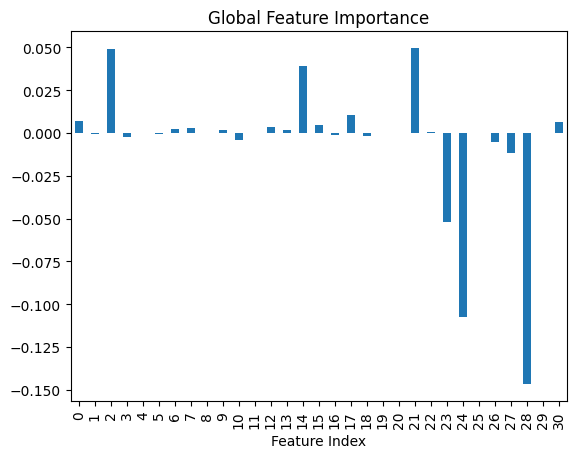

In [ ]:


all_feature_importance_df['Average'].plot(kind='bar', title='Global Feature Importance')

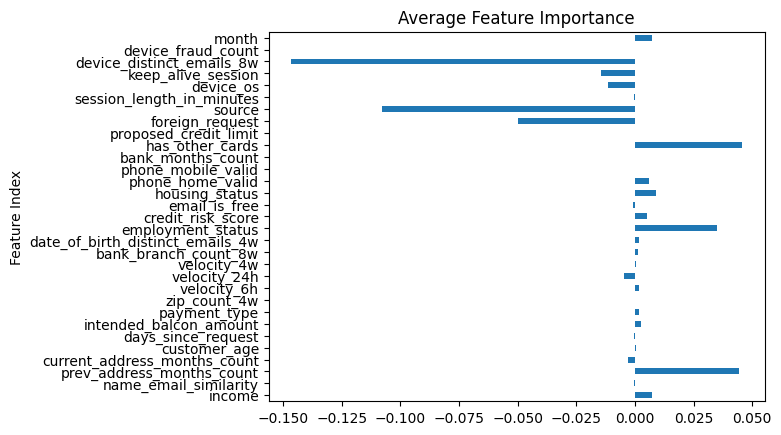

In [ ]:
import matplotlib.pyplot as plt

# Plotting the bar chart
ax = all_feature_importance_df['Average'].plot(kind='barh', title='Average Feature Importance')

# Setting custom x-axis labels
ax.set_yticklabels(x_train.columns.tolist(), ha='right')  # Customize rotation and alignment

# Show the plot
plt.show()


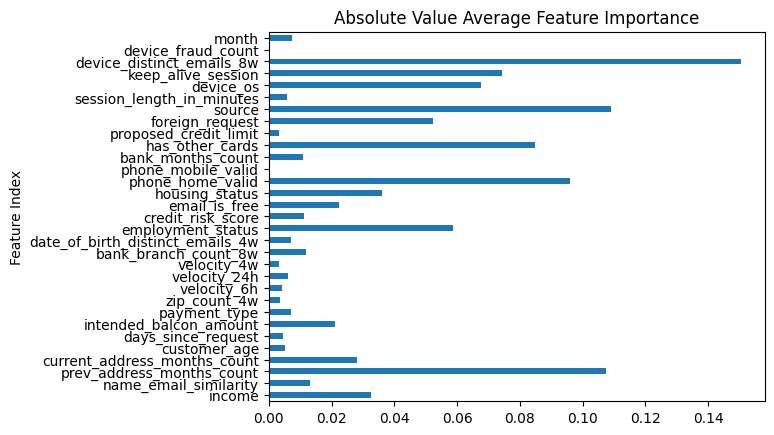

In [ ]:
ax = all_feature_importance_df['Absolute Value Average'].plot(kind='barh', title='Absolute Value Average Feature Importance')

# Setting custom x-axis labels
ax.set_yticklabels(x_train.columns.tolist(), ha='right')  # Customize rotation and alignment

# Show the plot
plt.show()

In [ ]:
all_feature_importance_df.to_csv('all_feature_importance_df.csv')